In [ ]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:98% !important;}
div.cell.code_cell.rendered{width:100%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
div.text_cell_render.rendered_html{font-size:18pt;}
div.text_cell_render.rendered_html{font-size:15pt;}
div.output {font-size:18pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:18pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:18pt;padding:5px;}
table.dataframe{font-size:18px;}
</style>
"""))

<b><font color="red" size="6">06_피마인디언_당뇨병발병예측<br><br>(로지스틱회귀분석=이진분류,분류분석)</font></b>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys # 최대한 출력을 많이해라 그런거 할지 몰라서 넣었음
from tensorflow.keras import utils # utils.to_categorical 원핫인코딩
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Input, Dense # 계산층

# 로지스틱 회귀분석 (이진분류)
## 1. 데이터셋 생성 및 전처리
- sigmoid는 s shape을 만들어주는 함수

In [6]:
df = pd.read_csv('data/pima-indians-diabetes.csv', 
                  comment='#',
                  header=None)
df.info() # 결측치 확인(없음)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       768 non-null    int64  
 1   1       768 non-null    int64  
 2   2       768 non-null    int64  
 3   3       768 non-null    int64  
 4   4       768 non-null    int64  
 5   5       768 non-null    float64
 6   6       768 non-null    float64
 7   7       768 non-null    int64  
 8   8       768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [7]:
df.shape

(768, 9)

#### 타겟 변수의 균형보기

In [10]:
# df[8]
df.iloc[:,-1].value_counts()

0    500
1    268
Name: 8, dtype: int64

In [11]:
df.head()

,0,1,2,3,4,5,6,7,8
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
# X_data = df.iloc[:-1].values

#### csv 파일을 numpy로 읽어오기 : np.loadtxt(결측치가 없는 경우), np.genfromtxt(결측치있을 경우)

In [2]:
# csv 파일을 numpy로 읽어오기 : np.loadtxt(결측치가 없는 경우), np.genfromtxt(결측치있을 경우)
dataset = np.loadtxt('data/pima-indians-diabetes.csv', 
                      encoding='utf-8',
                      delimiter=',')
dataset.shape

(768, 9)

#### 데이터 분할(독립,타겟) (train, test)

In [4]:
# 데이터 분할 : 학습데이터셋(모델학습용) + 시험데이터셋(모델평가용)
X_train = dataset[:700, :-1]
y_train = dataset[:700, -1]
X_test = dataset[700:, :-1]
y_test = dataset[700:, -1]
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((700, 8), (700,), (68, 8), (68,))

## 2. 모델 구성

In [12]:
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_11 (Dense)            (None, 32)                288       
                                                                 
 dense_12 (Dense)            (None, 16)                528       
                                                                 
 dense_13 (Dense)            (None, 1)                 17        
                                                                 
Total params: 833
Trainable params: 833
Non-trainable params: 0
_________________________________________________________________


## 3. 학습 과정 설정

In [13]:
model.compile(loss='binary_crossentropy',
              optimizer='adam',
              metrics=['binary_accuracy'])

## 4. 학습

In [14]:
%%time
hist = model.fit(X_train, y_train, # 훈련데이터
                 epochs=200, # 학습 횟수
                 batch_size=350, # 한번에 읽어들이는 데이터 양
#                  validation_data=(X_test,y_test), # 검증데이터
#                  validation_split=0.1, # 검증데이터 10%를 만들어서 검증해봄
                 verbose=0, # 학습로그내역표시 0=없음, 1=보통, 2=자세히
                 )

CPU times: total: 1.89 s
Wall time: 1.25 s


## 5. 모델 평가하기(학습과정 보기, 평가, 혼동행렬)
- 혼동행렬, 교차표, 성능평가지표 모두 같은 말

In [15]:
hist.history.keys()

dict_keys(['loss', 'binary_accuracy'])

### 학습과정 표시(학습데이터에 대한 loss와 accuracy)

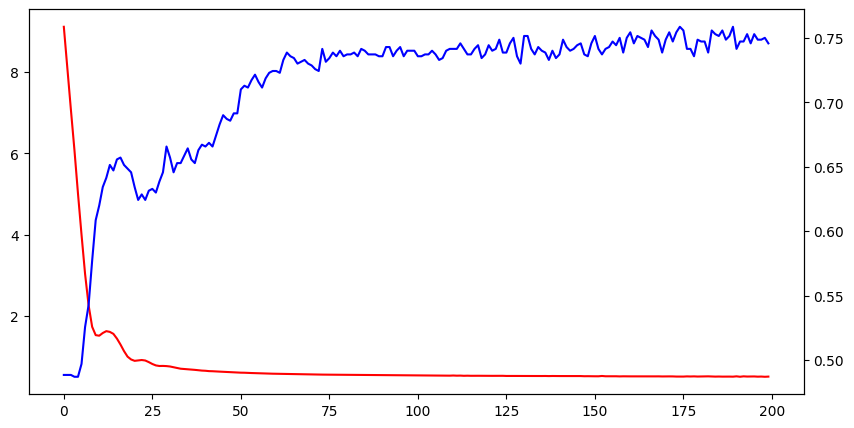

In [18]:
# 학습과정 표시(학습데이터에 대한 loss와 accuracy)
fig, loss_ax = plt.subplots(figsize=(10,5))
loss_ax.plot(hist.history['loss'], 'r')

acc_ax = loss_ax.twinx() # loss_ax와 x축을 공유하는 acc_ax
acc_ax.plot(hist.history.get('binary_accuracy'), 'b')

### 모델 평가

In [19]:
# 모델 평가(트레인데이터로 하면안됨)
model.evaluate(X_train, y_train)

22/22 [==============================] - 0s 2ms/step - loss: 0.5026 - binary_accuracy: 0.7600


[0.5025750398635864, 0.7599999904632568]

In [20]:
# 모델 평가(o)
model.evaluate(X_test, y_test)

3/3 [==============================] - 0s 3ms/step - loss: 0.6395 - binary_accuracy: 0.6618


[0.6394762992858887, 0.6617646813392639]

### 혼동행렬(교차표, 성능평가지표)
- 테스트 데이터 셋의 실제값과 예측값으로 그래프를 그리는 것

In [27]:
y_test[:5]

array([0., 1., 1., 0., 0.])

In [29]:
# 실제값 : y_test (68개)
y_test.shape
# 예측값
X_test
y_hat = (model.predict(X_test)>=0.5).astype(float)

y_hat[:5]

3/3 [==============================] - 0s 3ms/step


array([[0.],
       [0.],
       [0.],
       [1.],
       [0.]])

In [30]:
# 0을 0으로 예측한 경우의수 = TN (True)
TN = 0
# 0을 1로 예측한 경우의 수 = FP (False)
FP = 0
# 1을 0으로 예측한 경우의 수 = FN (False)
FN = 0
# 1을 1로 예측한 경우의 수 (True)
TP = 0

In [33]:
print(y_test.shape, y_hat.shape)
for y, h in zip(y_test, y_hat.reshape(-1)):
    if y==0 and h==0:
        TN += 1
    elif y==0 and h==1:
        FP += 1
    elif y==1 and h==0:
        FN += 1
    else:
        TP += 1
print(TN, FP)
print(FN, TP)

(68,) (68, 1)
35 6
17 10


### pd.crosstab(실제값, 예측값)

In [40]:
ctab = pd.crosstab(y_test,
                  y_hat.reshape(-1))
ctab.index.name = '실제값'
ctab.columns.name = '예측값'
ctab

예측값,0.0,1.0
실제값,,
0.0,35,6
1.0,17,10


In [42]:
ctab = pd.crosstab(y_test,
                  y_hat.reshape(-1),
                  rownames = ['실제값'],
                  colnames = ['예측값'],
                  )
ctab

예측값,0.0,1.0
실제값,,
0.0,35,6
1.0,17,10


### accuracy, precision, recall, f1 score

In [43]:
# 혼동행렬
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,
                y_hat.reshape(-1))

array([[35,  6],
       [17, 10]], dtype=int64)

In [45]:
# accuracy
print('accuracy :', (TN+TP) /  (TN+FP+FN+TP))
print('recall :', (TP) / (FN+TP) )
print('precision :', (TP) / (FP+TP) )

accuracy : 0.6617647058823529
recall : 0.37037037037037035
precision : 0.625


## 6. 모델 사용

In [49]:
X_test[0]

array([  2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.   ])

In [51]:
int(model.predict(np.array([[2, 122, 76, 27, 200, 35, 0.483, 26]]))>=0.5)

1/1 [==============================] - 0s 37ms/step


0

In [52]:
model.predict([[2, 122, 76, 27, 200, 35, 0.483, 26],
               [0, 122, 76, 27, 200, 35, 0.483, 26]]).astype(int)

1/1 [==============================] - 0s 49ms/step


array([[0],
       [0]])

# 분류 분석
- 1. 데이터셋 생성 및 전처리 : 훈련셋(600), 검증셋(100), 테스트셋(68)
- 2. 모델 생성(input8, output2) : 출력층 softmax(출력합을 1로 만들어주는 함수)
    * model.summary() 파라미터 수와 메모리 확인
- 3. 모델 학습 과정 설정 : loss = "categorical_crossentropy", metrics = ['accuracy'](평가지표)

- 4. 모델 학습 : 훈련셋과 검증셋
- 5. 모델 평가 : 그래프(hist.history), 평가(테스트셋), 교차표(테스트셋)
- 6. 모델 저장 및 사용 : predict결과에 argmax()

## 1. 데이터 셋 생성 및 전처리

In [23]:
dataset = np.loadtxt('data/pima-indians-diabetes.csv', encoding='utf-8',
                    delimiter=',',
#                     comments='#',
                    )
dataset.shape

(768, 9)

In [24]:
# 훈련셋(600), 검증셋(100), 테스트셋(68)
X_train = dataset[:600, :-1]
y_train = dataset[:600, -1]

X_val = dataset[600:700, :-1]
y_val = dataset[600:700, -1]

X_test = dataset[700:, :-1]
y_test = dataset[700:, -1]

X_train.shape, y_train.shape, X_val.shape, y_val.shape, X_test.shape, y_test.shape

((600, 8), (600,), (100, 8), (100,), (68, 8), (68,))

### 타겟변수의 원핫인코딩(분류분석)

In [25]:
# 타겟변수의 원핫인코딩 (분류분석)
print(y_train[:5])
print(utils.to_categorical(y_train[:5]))
Y_train = utils.to_categorical(y_train)
Y_val = utils.to_categorical(y_val)
Y_test = utils.to_categorical(y_test)
y_train.shape, Y_train.shape, Y_val.shape, Y_test.shape

[1. 0. 1. 0. 1.]
[[0. 1.]
 [1. 0.]
 [0. 1.]
 [1. 0.]
 [0. 1.]]


((600,), (600, 2), (100, 2), (68, 2))

## 2. 모델 생성(input8, output2)
- 과적합 줄이는 단계 추가 (dropout추가)

In [26]:
from tensorflow.keras.layers import Dropout
model = Sequential()
model.add(Input(shape=(8,)))
model.add(Dense(32, activation='relu'))

model.add(Dropout(0.2)) # 과적합을 해결하고자 두루뭉실하게 넘김

model.add(Dense(64, activation='relu'))

model.add(Dropout(0.1))

model.add(Dense(16, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(8, activation='relu'))
model.add(Dense(2, activation='softmax'))
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_5 (Dense)             (None, 32)                288       
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_6 (Dense)             (None, 64)                2112      
                                                                 
 dropout_1 (Dropout)         (None, 64)                0         
                                                                 
 dense_7 (Dense)             (None, 16)                1040      
                                                                 
 dropout_2 (Dropout)         (None, 16)                0         
                                                                 
 dense_8 (Dense)             (None, 8)                

## 3. 학습과정 설정

In [27]:
model.compile(loss='categorical_crossentropy',optimizer='nadam',metrics=['accuracy'])

## 4. 모델학습

In [28]:
hist = model.fit(X_train, Y_train,
                epochs=300,
                validation_data=(X_val, Y_val),
                verbose=1)

Epoch 1/300
19/19 [==============================] - 1s 15ms/step - loss: 7.5927 - accuracy: 0.6250 - val_loss: 1.3392 - val_accuracy: 0.3600
Epoch 2/300
19/19 [==============================] - 0s 4ms/step - loss: 2.6314 - accuracy: 0.5067 - val_loss: 1.0646 - val_accuracy: 0.5200
Epoch 3/300
19/19 [==============================] - 0s 4ms/step - loss: 1.4694 - accuracy: 0.5567 - val_loss: 0.8338 - val_accuracy: 0.5200
Epoch 4/300
19/19 [==============================] - 0s 4ms/step - loss: 1.2580 - accuracy: 0.5050 - val_loss: 0.6894 - val_accuracy: 0.5900
Epoch 5/300
19/19 [==============================] - 0s 4ms/step - loss: 1.1610 - accuracy: 0.5667 - val_loss: 0.6723 - val_accuracy: 0.6100
Epoch 6/300
19/19 [==============================] - 0s 4ms/step - loss: 0.9598 - accuracy: 0.5900 - val_loss: 0.6623 - val_accuracy: 0.6500
Epoch 7/300
19/19 [==============================] - 0s 5ms/step - loss: 0.8411 - accuracy: 0.6150 - val_loss: 0.6639 - val_accuracy: 0.6900
Epoch 8/300


Epoch 59/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6498 - accuracy: 0.6583 - val_loss: 0.6230 - val_accuracy: 0.6700
Epoch 60/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6252 - accuracy: 0.6600 - val_loss: 0.6263 - val_accuracy: 0.6700
Epoch 61/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6287 - accuracy: 0.6583 - val_loss: 0.6157 - val_accuracy: 0.6700
Epoch 62/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6269 - accuracy: 0.6567 - val_loss: 0.6107 - val_accuracy: 0.6700
Epoch 63/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6425 - accuracy: 0.6517 - val_loss: 0.6107 - val_accuracy: 0.6700
Epoch 64/300
19/19 [==============================] - 0s 5ms/step - loss: 0.6383 - accuracy: 0.6567 - val_loss: 0.6093 - val_accuracy: 0.6700
Epoch 65/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6367 - accuracy: 0.6550 - val_loss: 0.6128 - val_accuracy: 0.6700
Epoch 

19/19 [==============================] - 0s 4ms/step - loss: 0.5977 - accuracy: 0.6750 - val_loss: 0.5896 - val_accuracy: 0.6800
Epoch 117/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5962 - accuracy: 0.6917 - val_loss: 0.5963 - val_accuracy: 0.6900
Epoch 118/300
19/19 [==============================] - 0s 3ms/step - loss: 0.5973 - accuracy: 0.6783 - val_loss: 0.5934 - val_accuracy: 0.7000
Epoch 119/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5960 - accuracy: 0.6717 - val_loss: 0.5787 - val_accuracy: 0.7100
Epoch 120/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5905 - accuracy: 0.6883 - val_loss: 0.5752 - val_accuracy: 0.7300
Epoch 121/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5931 - accuracy: 0.6717 - val_loss: 0.5785 - val_accuracy: 0.7100
Epoch 122/300
19/19 [==============================] - 0s 4ms/step - loss: 0.6112 - accuracy: 0.6833 - val_loss: 0.5812 - val_accuracy: 0.6800
Epoch 123/300

19/19 [==============================] - 0s 4ms/step - loss: 0.5716 - accuracy: 0.7067 - val_loss: 0.5589 - val_accuracy: 0.7000
Epoch 174/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5667 - accuracy: 0.7050 - val_loss: 0.5539 - val_accuracy: 0.7000
Epoch 175/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5697 - accuracy: 0.7000 - val_loss: 0.5525 - val_accuracy: 0.7400
Epoch 176/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5667 - accuracy: 0.7133 - val_loss: 0.5543 - val_accuracy: 0.7300
Epoch 177/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5586 - accuracy: 0.7283 - val_loss: 0.5530 - val_accuracy: 0.6900
Epoch 178/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5671 - accuracy: 0.7067 - val_loss: 0.5446 - val_accuracy: 0.7300
Epoch 179/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5536 - accuracy: 0.7200 - val_loss: 0.5469 - val_accuracy: 0.7000
Epoch 180/300

19/19 [==============================] - 0s 5ms/step - loss: 0.5340 - accuracy: 0.7283 - val_loss: 0.5253 - val_accuracy: 0.7400
Epoch 231/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5495 - accuracy: 0.7300 - val_loss: 0.5195 - val_accuracy: 0.7400
Epoch 232/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5424 - accuracy: 0.7250 - val_loss: 0.5192 - val_accuracy: 0.7300
Epoch 233/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5372 - accuracy: 0.7183 - val_loss: 0.5227 - val_accuracy: 0.7100
Epoch 234/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5415 - accuracy: 0.7417 - val_loss: 0.5173 - val_accuracy: 0.7400
Epoch 235/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5570 - accuracy: 0.7083 - val_loss: 0.5224 - val_accuracy: 0.7300
Epoch 236/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5389 - accuracy: 0.7217 - val_loss: 0.5179 - val_accuracy: 0.7500
Epoch 237/300

19/19 [==============================] - 0s 4ms/step - loss: 0.5198 - accuracy: 0.7317 - val_loss: 0.5090 - val_accuracy: 0.7300
Epoch 288/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5256 - accuracy: 0.7583 - val_loss: 0.5113 - val_accuracy: 0.7400
Epoch 289/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5080 - accuracy: 0.7567 - val_loss: 0.5100 - val_accuracy: 0.7500
Epoch 290/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5226 - accuracy: 0.7450 - val_loss: 0.5066 - val_accuracy: 0.7600
Epoch 291/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5177 - accuracy: 0.7400 - val_loss: 0.5079 - val_accuracy: 0.7500
Epoch 292/300
19/19 [==============================] - 0s 5ms/step - loss: 0.5237 - accuracy: 0.7300 - val_loss: 0.4932 - val_accuracy: 0.7900
Epoch 293/300
19/19 [==============================] - 0s 4ms/step - loss: 0.5350 - accuracy: 0.7317 - val_loss: 0.5032 - val_accuracy: 0.7600
Epoch 294/300

## 5. 학습과정 살펴보기

In [29]:
hist.history.keys()

dict_keys(['loss', 'accuracy', 'val_loss', 'val_accuracy'])

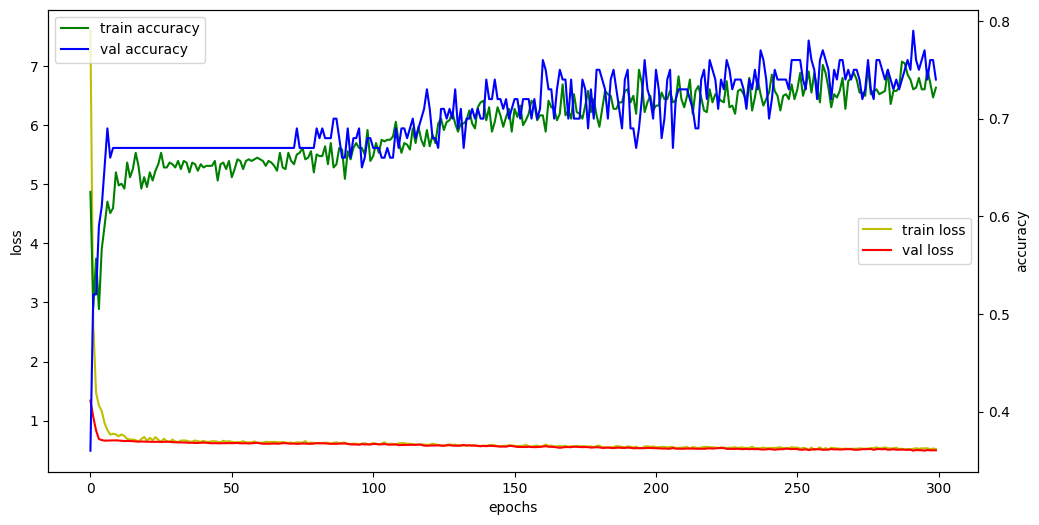

In [41]:
fig, loss_ax = plt.subplots(figsize=(12,6))
loss_ax.plot(hist.history['loss'], 'y', label='train loss')
loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')

acc_ax = loss_ax.twinx()
acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')

loss_ax.set_xlabel('epochs')
loss_ax.set_ylabel('loss')
acc_ax.set_ylabel('accuracy')

loss_ax.legend(loc='center right')
acc_ax.legend()

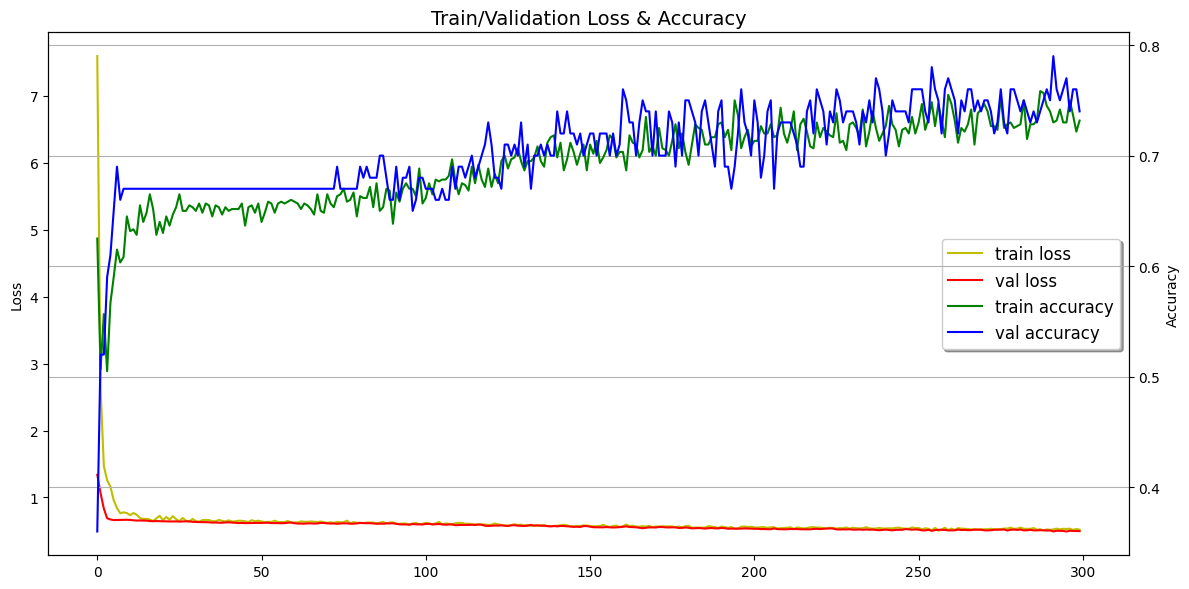

In [43]:
import matplotlib.pyplot as plt

fig, loss_ax = plt.subplots(figsize=(12, 6))

# 첫 번째 축: Loss
l1, = loss_ax.plot(hist.history['loss'], 'y', label='train loss')
l2, = loss_ax.plot(hist.history['val_loss'], 'r', label='val loss')
loss_ax.set_ylabel('Loss')

# 두 번째 축: Accuracy
acc_ax = loss_ax.twinx()
l3, = acc_ax.plot(hist.history['accuracy'], 'g', label='train accuracy')
l4, = acc_ax.plot(hist.history['val_accuracy'], 'b', label='val accuracy')
acc_ax.set_ylabel('Accuracy')

# 두 축의 선을 모두 합쳐서 legend에 넣기
lines = [l1, l2, l3, l4]
labels = [line.get_label() for line in lines]
loss_ax.legend(lines, labels, loc='center right', fontsize=12, frameon=True, shadow=True)

# 기타 설정
plt.title("Train/Validation Loss & Accuracy", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()


## 6. 모델 평가 & 교차표

In [47]:
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"loss : {loss}, 정확도 : {accuracy}")

loss : 0.6070723533630371, 정확도 : 0.7058823704719543


In [48]:
# 교차표
Y_test.argmax(axis=1) # 실제값(y_test)

array([0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1,
       0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0,
       1, 0], dtype=int64)

In [50]:
y_hat = model.predict(X_test) # 예측값(왼쪽:0이나올확률, 오른쪽:1이나올확률)
y_hat = model.predict(X_test).argmax(axis=1)
y_hat

3/3 [==============================] - 0s 2ms/step


array([0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       0, 0], dtype=int64)

#### pd.crosstab

In [54]:
pd.crosstab(y_test, y_hat, rownames=['실제값'], colnames=['예측값'])

예측값,0,1
실제값,,
0.0,41,0
1.0,20,7


### sklearn confusion_matrix

In [56]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test, y_hat)

array([[41,  0],
       [20,  7]], dtype=int64)

## 7. 모델 저장 및 사용

In [59]:
from tensorflow.keras.models import save_model, load_model
#model.save('model/06_pima.h5')
save_model(model, 'model/06_pima.h5')

In [60]:
model2 = load_model('model/06_pima.h5')

In [67]:
# X_test[1]

In [66]:
pred = model2.predict( [[2.   , 122.   ,  76.   ,  27.   , 200.   ,  35.9  ,   0.483,
        26.],
                [6.   , 125.   ,  78.   ,  31.   ,   0.   ,  27.6  ,   0.565,
        49. ]])
pred.argmax(axis=1)

1/1 [==============================] - 0s 41ms/step


array([0, 0], dtype=int64)

In [68]:
np.argmax(pred, axis=1)

array([0, 0], dtype=int64)